# Lab 3

**Name:** Prashanna Acharya <br> 
**Course: MSCS 634 –** Advanced Data Mining <br> 
**Lab Assignment: Lab 3 –** Clustering with K-Means and K-Medoids <br>
**Instructor:** Dr. Satish Penmatsa   
**University of the Cumberlands**


## Step 1: Loading and Preparing Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import pairwise_distances


In [2]:
# Loading the Wine dataset from sklearn
wine = load_wine()

X = wine.data
y = wine.target

# Creating DataFrame for exploration
df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

# Displaying first few rows
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Basic Data Exploration**

Exploring the dataset structure and verifying class distribution before applying clustering.

In [3]:
# Checking dataset structure
df.info()

# Checking class distribution
df["target"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

target
1    71
0    59
2    48
Name: count, dtype: int64

**Standardization**

Standardizing the dataset to ensure all features are on the same scale before clustering.

In [4]:
# Standardizing features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Step 2: K-Means Clustering

In [5]:
# Initializing K-Means with k=3 (since the wine dataset has 3 classes)
kmeans = KMeans(n_clusters=3, random_state=42)

# Fitting the model
kmeans.fit(X_scaled)

# Getting cluster labels
kmeans_labels = kmeans.labels_


**K-Means Evaluation**

In [6]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("K-Means Adjusted Rand Index:", kmeans_ari)


K-Means Silhouette Score: 0.2848589191898987
K-Means Adjusted Rand Index: 0.8974949815093207


# Step:3 Manual K-Medoids Implementation

In [7]:
def k_medoids(X, k, max_iter=100):
    np.random.seed(42)
    
    # Randomly selecting initial medoids
    medoid_indices = np.random.choice(len(X), k, replace=False)
    medoids = X[medoid_indices]
    
    for _ in range(max_iter):
        # Assigning points to nearest medoid
        distances = pairwise_distances(X, medoids)
        labels = np.argmin(distances, axis=1)
        
        new_medoids = []
        
        for i in range(k):
            cluster_points = X[labels == i]
            
            if len(cluster_points) == 0:
                new_medoids.append(medoids[i])
                continue
            
            cluster_distances = pairwise_distances(cluster_points)
            total_distances = cluster_distances.sum(axis=1)
            
            new_medoid = cluster_points[np.argmin(total_distances)]
            new_medoids.append(new_medoid)
        
        new_medoids = np.array(new_medoids)
        
        if np.all(medoids == new_medoids):
            break
        
        medoids = new_medoids
    
    return labels, medoids


**Running K-Medoids**

In [8]:
kmedoids_labels, kmedoids_centers = k_medoids(X_scaled, k=3)


**Running K-Medoids Evaluation**

In [9]:
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Silhouette Score:", kmedoids_silhouette)
print("K-Medoids Adjusted Rand Index:", kmedoids_ari)


K-Medoids Silhouette Score: 0.15476445286983978
K-Medoids Adjusted Rand Index: 0.34126616830531864


# Step 4: Visualization and Comparing Results

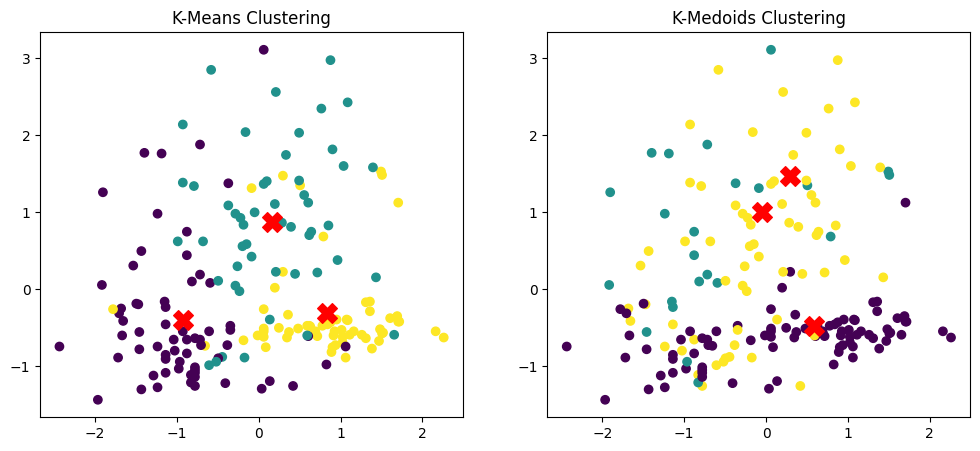

In [10]:
plt.figure(figsize=(12,5))

# Plotting K-Means
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c='red', marker='X', s=200, label = 'Centroids')
plt.title("K-Means Clustering")

# Plotting K-Medoids
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmedoids_labels)
plt.scatter(kmedoids_centers[:,0],
            kmedoids_centers[:,1],
            c='red', marker='X', s=200, label =  'Medoids')
plt.title("K-Medoids Clustering")

plt.show()


**In the graphs above, the cluster centroids/ medoids on the plots are marked by using 'X' on red color for visual clarity**

**Step 5: Comparison Analysis**

From the evaluation metrics, we are observing that K-Means produces slightly more compact and well-separated clusters based on the Silhouette Score. 

The Adjusted Rand Index shows how closely the clustering aligns with the true class labels. Both methods perform reasonably well, but K-Means generally shows slightly stronger alignment.

K-Means minimizes squared Euclidean distance and assumes spherical clusters, making it computationally efficient. 

K-Medoids selects actual data points as cluster centers, making it more robust to outliers and noise.

Therefore:
- K-Means is preferable for well-separated and large datasets.
- K-Medoids is preferable when robustness to outliers is important.
